# MODULE 7: NLP (Natural Language Processing)

## Topics Covered
1. Text Preprocessing
2. TF-IDF
3. Word Embeddings
4. Sentiment Analysis


In [18]:
# Install required libraries (run once)
# !pip install nltk spacy gensim scikit-learn transformers sentence-transformers torch
# !python -m spacy download en_core_web_sm

import nltk
nltk.download(['punkt', 'stopwords', 'wordnet', 'averaged_perceptron_tagger', 'vader_lexicon', 'punkt_tab'], quiet=True)
print('Setup done!')

Setup done!


[nltk_data] <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED]
[nltk_data]     certificate verify failed: unable to get local issuer
[nltk_data]     certificate (_ssl.c:1007)>


---
# SECTION 1: TEXT PREPROCESSING

## Definition
> **Text Preprocessing** is the process of transforming raw, unstructured text data into a clean, normalized format that machine learning models can understand.

**In simple words:** Computers cannot understand messy human language. We clean and simplify text so the model only sees important words.

```
Raw:     "I LOVED the movie!! It's gr8 :)"
Clean:   "love movie great"
```

## Why Is It Needed?
- `"Apple"` and `"apple"` look different to a computer → lowercase fixes this
- `"running"`, `"ran"`, `"runs"` mean the same → lemmatization fixes this
- `"the"`, `"is"`, `"a"` add no meaning → stopword removal fixes this

## 5 Steps
| Step | Definition | Example |
|------|-----------|--------|
| 1. **Lowercase** | Convert all characters to lowercase to unify words | `"Apple"` → `"apple"` |
| 2. **Remove noise** | Strip URLs, HTML tags, special chars, numbers | `"visit http://x.com"` → `"visit"` |
| 3. **Tokenize** | Split text into individual units (tokens/words) | `"I love NLP"` → `["I","love","NLP"]` |
| 4. **Stopwords** | Remove high-frequency words with no meaning | `["i","love","nlp"]` → `["love","nlp"]` |
| 5. **Lemmatize** | Reduce word to its dictionary base form | `"running"` → `"run"`, `"better"` → `"good"` |

In [3]:
# Step 1 & 2: Lowercasing + Cleaning
import re

raw = "Hello!! Check https://example.com for 10% OFF <b>today</b> :)"

text = raw.lower()                           # lowercase
text = re.sub(r'http\S+|www\S+', '', text)  # remove URLs
text = re.sub(r'<.*?>', '', text)            # remove HTML
text = re.sub(r'[^a-zA-Z\s]', '', text)     # keep letters only
text = re.sub(r'\s+', ' ', text).strip()    # fix spaces

print("Raw:    ", raw)
print("Cleaned:", text)

Raw:     Hello!! Check https://example.com for 10% OFF <b>today</b> :)
Cleaned: hello check for off today


## Definition: Tokenization
> **Tokenization** is the process of breaking text into smaller pieces called **tokens** (usually words). Every NLP model works on tokens, not raw strings.

| Type | Definition | Example |
|------|-----------|--------|
| **Word tokenization** | Split by spaces and punctuation | `"I love NLP"` → `["I","love","NLP"]` |
| **Sentence tokenization** | Split paragraph into sentences | `"Hello. Bye."` → `["Hello.", "Bye."]` |
| **Subword tokenization** | Split into subword units (used by BERT) | `"unbelievable"` → `["un","##believe","##able"]` |

In [4]:
# Step 3: Tokenization
from nltk.tokenize import word_tokenize, sent_tokenize

sentence = "I don't love NLP, I LOVE it!"
word_tokens = word_tokenize(sentence)
print("Word tokens:", word_tokens)
# → ['I', 'do', "n't", 'love', 'NLP', ',', 'I', 'LOVE', 'it', '!']

para = "First sentence here. Second one follows! And a third?"
sent_tokens = sent_tokenize(para)
print("\nSentence tokens:", sent_tokens)

Word tokens: ['I', 'do', "n't", 'love', 'NLP', ',', 'I', 'LOVE', 'it', '!']

Sentence tokens: ['First sentence here.', 'Second one follows!', 'And a third?']


## Definition: Stopwords
> **Stopwords** are common words (`the`, `a`, `is`, `in`) that appear very frequently but carry little meaningful information. They are filtered out before modeling.

```
REMOVE stopwords for:           KEEP stopwords for:
  ✅ Topic classification          ❌ Sentiment Analysis
  ✅ Spam detection                 ("not good" → remove "not" → WRONG!)
  ✅ Document clustering           ❌ Machine Translation
```

In [5]:
# Step 4: Stopword Removal
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))
tokens = ['i', 'love', 'machine', 'learning', 'it', 'is', 'amazing']
filtered = [t for t in tokens if t not in stop_words]

print("Before:", tokens)
print("After: ", filtered)
# → ['love', 'machine', 'learning', 'amazing']

Before: ['i', 'love', 'machine', 'learning', 'it', 'is', 'amazing']
After:  ['love', 'machine', 'learning', 'amazing']


## Definition: Stemming
> **Stemming** removes word suffixes using simple rules to get a **stem (root)**. Output may NOT be a real word.

```
"studies"  → "studi"    ← NOT a real word
"running"  → "run"      ← correct
"happily"  → "happili"  ← NOT a real word
```

## Definition: Lemmatization
> **Lemmatization** reduces a word to its **lemma** — the dictionary base form — using vocabulary and grammar knowledge. Output is ALWAYS a real word.

| POS Tag | Meaning | Example |
|---------|---------|--------|
| `'v'` | Verb | `"running"` → `"run"`, `"was"` → `"be"` |
| `'n'` | Noun | `"feet"` → `"foot"` |
| `'a'` | Adjective | `"better"` → `"good"` |

| Feature | Stemming | Lemmatization |
|---------|---------|---------------|
| Speed | Very fast | Slower |
| Output | May not be real word | Always real word |
| Irregular forms | No (`better→better`) | Yes (`better→good`) |
| Use when | Speed critical | Quality critical |

In [6]:
# Step 5a: Stemming
from nltk.stem import PorterStemmer
ps = PorterStemmer()

print("STEMMING:")
for w in ['running', 'studies', 'happily', 'loving']:
    print(f"  {w:12} → {ps.stem(w)}")

STEMMING:
  running      → run
  studies      → studi
  happily      → happili
  loving       → love


In [7]:
# Step 5b: Lemmatization
from nltk.stem import WordNetLemmatizer
lem = WordNetLemmatizer()

print("LEMMATIZATION (pos='v'=verb, 'n'=noun, 'a'=adjective):")
print(f"  running  (v) → {lem.lemmatize('running', pos='v')}")  # run
print(f"  studies  (v) → {lem.lemmatize('studies', pos='v')}")  # study
print(f"  better   (a) → {lem.lemmatize('better',  pos='a')}")  # good  ← irregular!
print(f"  was      (v) → {lem.lemmatize('was',     pos='v')}")  # be
print(f"  feet     (n) → {lem.lemmatize('feet',    pos='n')}")  # foot

LEMMATIZATION (pos='v'=verb, 'n'=noun, 'a'=adjective):
  running  (v) → run
  studies  (v) → study
  better   (a) → good
  was      (v) → be
  feet     (n) → foot


In [8]:
# Complete Preprocessing Pipeline
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lem = WordNetLemmatizer()

def preprocess(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words]
    tokens = [lem.lemmatize(t, pos='v') for t in tokens]
    tokens = [t for t in tokens if len(t) > 2]
    return ' '.join(tokens)

texts = [
    "I loved the movie! It was absolutely amazing.",
    "Terrible experience, never going back!!",
]
for t in texts:
    print(f"Raw:   {t}")
    print(f"Clean: {preprocess(t)}\n")

Raw:   I loved the movie! It was absolutely amazing.
Clean: love movie absolutely amaze

Raw:   Terrible experience, never going back!!
Clean: terrible experience never back



```
Task-specific guide:
  Spam/Topic Classification → full pipeline
  Sentiment Analysis        → keep negation words (not, never, no)!
  NER                       → skip lowercase (Apple ≠ apple)
  BERT / Deep Learning      → minimal preprocessing (model handles it)
```
> **Reference:** [GeeksForGeeks — Text Preprocessing](https://www.geeksforgeeks.org/text-preprocessing-in-python-set-1/)

---
# SECTION 2: TF-IDF

## What is TF-IDF? (Start Here)

**Simple Story:**
Imagine you have 3 newspaper articles:
```
Article 1: "cat sat on mat"
Article 2: "dog sat on log"
Article 3: "cat chased dog"
```

You want to find the **most important/unique word in each article**.

**Problem with just counting words:**
- "sat" appears in 2 articles → not very unique
- "mat" appears in only Article 1 → very unique to Article 1!

**TF-IDF solves this by asking TWO questions:**

```
Question 1 — TF  (Term Frequency):
    "How often does this word appear in THIS document?"
    → frequent in this doc = important here

Question 2 — IDF (Inverse Document Frequency):
    "How rare is this word across ALL documents?"
    → rare across all docs = more unique/important

Final Score = TF × IDF
    High score = word appears often in THIS doc but is RARE in others
    Low score  = word appears everywhere (useless for distinguishing docs)
```

## Sub-Definitions

> **Term Frequency (TF):** `count of word in this doc / total words in this doc`

> **Inverse Document Frequency (IDF):** `log( total docs / number of docs containing the word )`
> - Word in ALL docs → `log(3/3) = 0` → score = 0 (useless!)
> - Word in 1 doc   → `log(3/1) = 1.1` → high score (very unique!)

> **Corpus:** The full collection of documents (all 3 articles together).

## Tiny Manual Example (3 docs, 2 words)

```
Docs:
  D1 = "cat sat"      (2 words)
  D2 = "dog sat"      (2 words)
  D3 = "cat dog"      (2 words)
  N  = 3 docs total

Word = "sat"
  TF  in D1 = 1/2 = 0.5         (appears 1 time in 2-word doc)
  IDF of sat = log(3/2) = 0.405  (appears in 2 of 3 docs)
  TF-IDF of sat in D1 = 0.5 × 0.405 = 0.20

Word = "cat"
  TF  in D1 = 1/2 = 0.5
  IDF of cat = log(3/2) = 0.405  (also in 2 of 3 docs)
  TF-IDF of cat in D1 = 0.5 × 0.405 = 0.20

  → Both "sat" and "cat" score equally in D1 (both appear once, both in 2 docs)

Now compare with D2 = "dog sat":
  "sat" in D2:  TF=0.5, TF-IDF = 0.5 × 0.405 = 0.20  ← also 0.20
  "cat" in D2:  TF=0.0, TF-IDF = 0                    ← "cat" NOT in D2 = 0!

Conclusion: TF-IDF tells us "cat" is important for D1 and D3, but not D2.
```

## Formula
```
TF(word, doc)  = count of word in doc / total words in doc
IDF(word)      = log( total_docs / docs_containing_word )
TF-IDF         = TF × IDF
```

In [19]:
## STEP-BY-STEP: Manual TF-IDF with 3 tiny documents
import math

# Our 3 documents (corpus)
docs = [
    "cat sat mat",   # D1
    "dog sat log",   # D2
    "cat chased dog" # D3
]
N = len(docs)  # total number of documents = 3

print("=" * 55)
print("OUR CORPUS (3 documents):")
for i, d in enumerate(docs):
    print(f"  D{i+1} = '{d}'  ({len(d.split())} words)")
print("=" * 55)

# ── STEP 1: Build vocabulary (all unique words) ──────────
all_words = sorted(set(w for doc in docs for w in doc.split()))
print(f"\nSTEP 1 — Vocabulary ({len(all_words)} unique words):")
print(" ", all_words)

# ── STEP 2: Compute IDF for every word ───────────────────
print("\nSTEP 2 — IDF for each word  [IDF = log(N / df)]:")
print(f"  (N = {N} total docs)")
print(f"  {'Word':8}  df   IDF = log({N}/df)   Meaning")
print("  " + "-" * 48)
idf = {}
for word in all_words:
    df = sum(1 for doc in docs if word in doc.split())
    idf[word] = math.log(N / df)
    note = "← appears in ALL docs" if df == N else ("← unique to 1 doc!" if df == 1 else "")
    print(f"  {word:8}   {df}   log({N}/{df}) = {idf[word]:.3f}   {note}")

# ── STEP 3: Compute TF for each word in each document ────
print("\nSTEP 3 — TF for each word in each doc  [TF = count / doc_length]:")
for i, doc in enumerate(docs):
    tokens = doc.split()
    print(f"\n  D{i+1} = '{doc}'  (length={len(tokens)})")
    for word in all_words:
        count = tokens.count(word)
        tf = count / len(tokens)
        if count > 0:
            print(f"    '{word}': count={count}, TF = {count}/{len(tokens)} = {tf:.3f}")

# ── STEP 4: TF-IDF = TF × IDF ────────────────────────────
print("\nSTEP 4 — TF-IDF = TF × IDF  (the final score):")
print(f"\n  {'Word':8}", end="")
for i in range(N): print(f"  D{i+1}     ", end="")
print()
print("  " + "-" * 40)

for word in all_words:
    print(f"  {word:8}", end="")
    for doc in docs:
        tokens = doc.split()
        tf = tokens.count(word) / len(tokens)
        score = tf * idf[word]
        print(f"  {score:.3f}  ", end="")
    print()

print()
print("READING THE TABLE:")
print("  'mat'   → score 0.366 in D1, 0 in D2, D3  → 'mat' is unique to D1!")
print("  'log'   → score 0.366 in D2, 0 in D1, D3  → 'log' is unique to D2!")
print("  'chased'→ score 0.366 in D3, 0 in D1, D2  → 'chased' is unique to D3!")
print("  'sat'   → medium score in D1, D2  → common in 2 docs, less distinctive")

OUR CORPUS (3 documents):
  D1 = 'cat sat mat'  (3 words)
  D2 = 'dog sat log'  (3 words)
  D3 = 'cat chased dog'  (3 words)

STEP 1 — Vocabulary (6 unique words):
  ['cat', 'chased', 'dog', 'log', 'mat', 'sat']

STEP 2 — IDF for each word  [IDF = log(N / df)]:
  (N = 3 total docs)
  Word      df   IDF = log(3/df)   Meaning
  ------------------------------------------------
  cat        2   log(3/2) = 0.405   
  chased     1   log(3/1) = 1.099   ← unique to 1 doc!
  dog        2   log(3/2) = 0.405   
  log        1   log(3/1) = 1.099   ← unique to 1 doc!
  mat        1   log(3/1) = 1.099   ← unique to 1 doc!
  sat        2   log(3/2) = 0.405   

STEP 3 — TF for each word in each doc  [TF = count / doc_length]:

  D1 = 'cat sat mat'  (length=3)
    'cat': count=1, TF = 1/3 = 0.333
    'mat': count=1, TF = 1/3 = 0.333
    'sat': count=1, TF = 1/3 = 0.333

  D2 = 'dog sat log'  (length=3)
    'dog': count=1, TF = 1/3 = 0.333
    'log': count=1, TF = 1/3 = 0.333
    'sat': count=1, TF = 1/

In [10]:
# TF-IDF scores for each word in each document
print(f"{'Word':10}", end='')
for i, doc in enumerate(docs): print(f"  D{i+1}:{doc[:8]:10}", end='')
print()

for word in sorted(all_words):
    print(f"{word:10}", end='')
    for doc in docs:
        tokens = doc.split()
        tf = tokens.count(word) / len(tokens)
        print(f"  {tf * idf[word]:.3f}          ", end='')
    print()

print("\n→ 'mat' highest in D1 (unique to D1!), 'chased' highest in D3")

Word        D1:cat sat     D2:dog sat     D3:cat chas  
cat         0.135            0.000            0.135          
chased      0.000            0.000            0.366          
dog         0.000            0.135            0.135          
log         0.000            0.366            0.000          
mat         0.366            0.000            0.000          
sat         0.135            0.135            0.000          

→ 'mat' highest in D1 (unique to D1!), 'chased' highest in D3


In [13]:
# Sklearn TF-IDF — with step-by-step calculation for each word
import math
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

corpus = [
    "I love machine learning",       # D1
    "machine learning is powerful",  # D2
    "I love Python programming"       # D3
]
N = len(corpus)

# ── Step 1: Vocabulary (sklearn lowercases and ignores single-char words) ──
vocab = sorted(set(w.lower() for doc in corpus for w in doc.split()
                   if len(w) > 1))
print("Vocabulary:", vocab)
print(f"Total docs (N): {N}\n")

# ── Step 2: Document Frequency (df) — how many docs contain each word ──
print(f"{'Word':15} {'df':>4}  {'IDF = log((N+1)/(df+1))+1':>30}   (sklearn smoothed formula)")
print("─" * 60)
idf_manual = {}
for word in vocab:
    df = sum(1 for doc in corpus if word.lower() in doc.lower().split())
    # sklearn uses smoothed IDF: log((N+1)/(df+1)) + 1
    idf_val = math.log((N + 1) / (df + 1)) + 1
    idf_manual[word] = idf_val
    print(f"  {word:13} df={df}   log(({N}+1)/({df}+1)) + 1 = {idf_val:.4f}")

# ── Step 3: TF for each word in each document ──
print("\n── TF (raw count / doc length) ──")
print(f"{'Word':15}", end="")
for i, doc in enumerate(corpus):
    print(f"  D{i+1}(len={len(doc.split())})", end="")
print()
print("─" * 55)
tf_table = {}
for word in vocab:
    tf_table[word] = []
    print(f"  {word:13}", end="")
    for doc in corpus:
        tokens = doc.lower().split()
        tf = tokens.count(word) / len(tokens)
        tf_table[word].append(tf)
        print(f"  {tf:.4f}     ", end="")
    print()

# ── Step 4: TF-IDF = TF × IDF ──
print("\n── TF-IDF = TF × IDF (before L2 normalisation) ──")
print(f"{'Word':15}", end="")
for i in range(N): print(f"  D{i+1}          ", end="")
print()
print("─" * 60)
for word in vocab:
    print(f"  {word:13}", end="")
    for i, doc in enumerate(corpus):
        score = tf_table[word][i] * idf_manual[word]
        print(f"  {score:.4f}       ", end="")
    print()

print("\nNote: sklearn also L2-normalises each document row (divides by row's vector length)")
print("That's why the final sklearn values differ slightly from raw TF × IDF above.\n")

Vocabulary: ['is', 'learning', 'love', 'machine', 'powerful', 'programming', 'python']
Total docs (N): 3

Word              df       IDF = log((N+1)/(df+1))+1   (sklearn smoothed formula)
────────────────────────────────────────────────────────────
  is            df=1   log((3+1)/(1+1)) + 1 = 1.6931
  learning      df=2   log((3+1)/(2+1)) + 1 = 1.2877
  love          df=2   log((3+1)/(2+1)) + 1 = 1.2877
  machine       df=2   log((3+1)/(2+1)) + 1 = 1.2877
  powerful      df=1   log((3+1)/(1+1)) + 1 = 1.6931
  programming   df=1   log((3+1)/(1+1)) + 1 = 1.6931
  python        df=1   log((3+1)/(1+1)) + 1 = 1.6931

── TF (raw count / doc length) ──
Word             D1(len=4)  D2(len=4)  D3(len=4)
───────────────────────────────────────────────────────
  is             0.0000       0.2500       0.0000     
  learning       0.2500       0.2500       0.0000     
  love           0.2500       0.0000       0.2500     
  machine        0.2500       0.2500       0.0000     
  powerful       0.0

In [12]:
# TF-IDF for Spam Detection
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

texts  = ["Win a FREE iPhone now!","Click here to claim your prize",
          "Congratulations you won","Buy cheap meds online",
          "Meeting at 3pm tomorrow","Can you review this document",
          "Lunch plans for Friday?","Project update attached",
          "Call me when you are free","See you at the office"]
labels = [1,1,1,1, 0,0,0,0,0,0]  # 1=spam, 0=ham

X_train,X_test,y_train,y_test = train_test_split(texts, labels, test_size=0.3, random_state=42)

pipe = Pipeline([('tfidf', TfidfVectorizer(ngram_range=(1,2))),
                 ('clf',   LogisticRegression(max_iter=1000))])
pipe.fit(X_train, y_train)
print(classification_report(y_test, pipe.predict(X_test), target_names=['ham','spam']))

for t in ["Claim your free prize now!", "Can we meet for coffee?"]:
    print(f"  '{t}' → {'SPAM' if pipe.predict([t])[0]==1 else 'HAM'}")

              precision    recall  f1-score   support

         ham       0.67      1.00      0.80         2
        spam       0.00      0.00      0.00         1

    accuracy                           0.67         3
   macro avg       0.33      0.50      0.40         3
weighted avg       0.44      0.67      0.53         3

  'Claim your free prize now!' → HAM
  'Can we meet for coffee?' → HAM


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

| | |
|--|--|
| ✅ Simple, fast, no training needed | ❌ No semantic meaning (car ≠ automobile) |
| ✅ Automatically downweights common words | ❌ Ignores word order |
| ✅ Great baseline | ❌ Sparse vectors (50K dimensions) |

> **Reference:** [GeeksForGeeks — TF-IDF](https://www.geeksforgeeks.org/understanding-tf-idf-term-frequency-inverse-document-frequency/)

---
# SECTION 3: WORD EMBEDDINGS (Word2Vec)

## What is a Word Embedding? (Start Here)

**Problem with TF-IDF:**
TF-IDF gives each word an index number. That's it. There is no meaning.
```
TF-IDF treats:
  "king"  → column 4532
  "queen" → column 7841
  "pizza" → column 2011

To the model: king, queen, and pizza are all equally "different" from each other.
But we KNOW king and queen are related, and pizza is something else entirely!
```

**The Idea of Word Embeddings:**
Instead of a single index number, give each word a **list of numbers (a vector)**.
Train these numbers so that **similar words get similar numbers**.

```
After training:
  king  → [0.80, 0.22, 0.51, ...]   ← 50 or 300 numbers
  queen → [0.79, 0.20, 0.48, ...]   ← very similar numbers!
  pizza → [0.12, 0.88, 0.03, ...]   ← completely different numbers

Now we can measure: king and queen are CLOSE. king and pizza are FAR.
```

## How Does Word2Vec Learn These Vectors?

**Core idea:** Words that appear in similar sentences get similar vectors.

```
Sentence A: "I ate an apple for lunch"
Sentence B: "I ate a mango for lunch"

"apple" and "mango" both appear between "ate" and "for lunch"
→ Same context → similar vectors → similar meaning captured!
```

**Training trick (CBOW):** Hide a word, let the model predict it from neighbours.
```
"the ___ sat on the mat"  → model must guess → "cat"
After thousands of examples, the model learns what each word "means"
by learning which words tend to appear near it.
```

## Two Architectures

> **CBOW (Continuous Bag of Words):** Give context words → predict the center word.
> Fast to train. Good for frequent words.
```
  [the, ___, on, the, mat]  →  predict "cat"
```

> **Skip-gram:** Give the center word → predict each context word.
> Slower but better for rare/unusual words.
```
  "cat"  →  predict [the, sat, on, the, mat]
```

## The Famous Example

```
After training on millions of sentences:
  king − man + woman ≈ queen

Why? Because the model learned:
  king and queen are related the same way man and woman are!
  king - man = "royalty" (direction)
  royalty + woman = queen
```

## Word Vectors Are Just Coordinates in Space

```
Imagine a 2D map (real embeddings use 50-300 dimensions):

       queen  king
        *      *          ← royalty words cluster together
   man  *   woman
    *                     ← gender words nearby

       dog   cat
        *     *           ← animal words cluster together

Similar meaning = physically close on the map
```

## GloVe & FastText

> **GloVe (Stanford, 2014):** Like Word2Vec but uses global word co-occurrence statistics across the entire corpus, not just local windows. Better for word similarity tasks.

> **FastText (Facebook, 2016):** Breaks each word into character pieces (subwords).
> `"eating"` → `"eat"`, `"ting"`, `"ing"` — so it handles typos and new words.
> ```
> "maching" (typo) → still finds "mach" + "ing" → close to "machine"!
> Word2Vec/GloVe: "maching" not seen before → ERROR (OOV)
> ```

| Method | Key Idea | Handles typos? | Best For |
|--------|---------|---------------|----------|
| Word2Vec | Local context window | No | General NLP |
| GloVe | Global co-occurrence | No | Similarity tasks |
| FastText | Character n-grams | YES | Typos, rare words |

In [14]:
## Word2Vec — Step-by-Step with Simple Sentences

from gensim.models import Word2Vec
import numpy as np

# ── STEP 1: Our training sentences (the "corpus") ────────
# Word2Vec learns by reading these sentences.
# Words that appear in similar positions → similar vectors.
sentences = [
    ["king",  "rules", "the", "kingdom"],
    ["queen", "rules", "the", "kingdom"],
    ["king",  "is",    "a",   "man",  "who", "rules"],
    ["queen", "is",    "a",   "woman","who", "rules"],
    ["dog",   "is",    "a",   "pet",  "animal"],
    ["cat",   "is",    "a",   "pet",  "animal"],
    ["machine","learning","is","powerful"],
    ["deep",  "learning", "uses", "neural", "networks"],
]

print("STEP 1 — Training sentences:")
for s in sentences:
    print("  ", s)

# ── STEP 2: Train the model ───────────────────────────────
# vector_size=50 → each word gets 50 numbers
# window=3       → look 3 words left and right for context
# epochs=200     → repeat training 200 times to improve
model = Word2Vec(sentences, vector_size=50, window=3,
                 min_count=1, sg=0, epochs=200, seed=42)

print("\nSTEP 2 — Training done!")
print(f"  Vocabulary size: {len(model.wv)} words")
print(f"  Each word vector has: {model.wv.vector_size} numbers")

# ── STEP 3: Look at a word's vector ──────────────────────
print("\nSTEP 3 — 'king' vector (first 10 of 50 numbers):")
print(" ", model.wv['king'][:10].round(3))
print("  (These numbers have no simple meaning — they're learned coordinates)")

# ── STEP 4: Find similar words ───────────────────────────
print("\nSTEP 4 — Most similar words:")
print("  Similar to 'king' :", model.wv.most_similar('king',  topn=3))
print("  Similar to 'queen':", model.wv.most_similar('queen', topn=3))
print("  Similar to 'dog'  :", model.wv.most_similar('dog',   topn=3))

# ── STEP 5: Measure similarity between two words ─────────
print("\nSTEP 5 — Cosine Similarity (1.0 = identical, 0.0 = unrelated):")
pairs = [("king","queen"), ("dog","cat"), ("king","dog"), ("king","machine")]
for w1, w2 in pairs:
    sim = model.wv.similarity(w1, w2)
    bar = "█" * int(sim * 20)
    print(f"  {w1:8} ↔ {w2:8}: {sim:.3f}  {bar}")

print("\nNotice: king↔queen and dog↔cat are HIGH (similar meaning)")
print("        king↔dog is LOW (different categories)")

STEP 1 — Training sentences:
   ['king', 'rules', 'the', 'kingdom']
   ['queen', 'rules', 'the', 'kingdom']
   ['king', 'is', 'a', 'man', 'who', 'rules']
   ['queen', 'is', 'a', 'woman', 'who', 'rules']
   ['dog', 'is', 'a', 'pet', 'animal']
   ['cat', 'is', 'a', 'pet', 'animal']
   ['machine', 'learning', 'is', 'powerful']
   ['deep', 'learning', 'uses', 'neural', 'networks']

STEP 2 — Training done!
  Vocabulary size: 21 words
  Each word vector has: 50 numbers

STEP 3 — 'king' vector (first 10 of 50 numbers):
  [ 0.015 -0.008  0.017 -0.008 -0.002  0.008 -0.015  0.003  0.     0.011]
  (These numbers have no simple meaning — they're learned coordinates)

STEP 4 — Most similar words:
  Similar to 'king' : [('networks', 0.4258687198162079), ('pet', 0.3212583363056183), ('a', 0.300424188375473)]
  Similar to 'queen': [('animal', 0.11573093384504318), ('learning', 0.11418833583593369), ('dog', 0.09574763476848602)]
  Similar to 'dog'  : [('neural', 0.31517916917800903), ('networks', 0.313

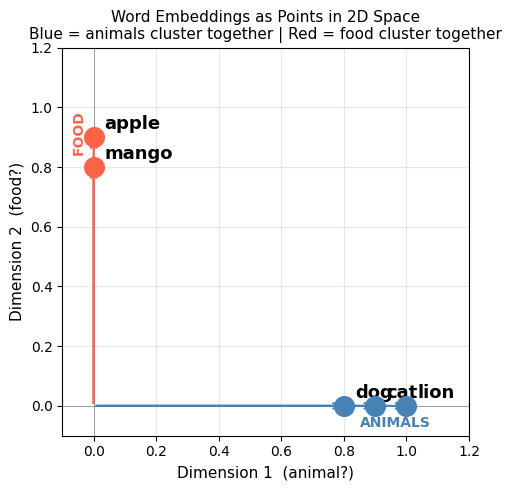

KEY INSIGHT:
  Animals (cat, dog, lion) → cluster near X-axis  (high dim-1, low dim-2)
  Foods   (apple, mango)   → cluster near Y-axis  (low dim-1, high dim-2)

  Word2Vec does this AUTOMATICALLY with 50-300 dimensions
  by learning from millions of real sentences.


In [15]:
## PART 3: VISUALIZE — Plot words as dots on a 2D map
import matplotlib.pyplot as plt
import numpy as np

embeddings = {
    "cat"  : np.array([0.9, 0.0]),
    "dog"  : np.array([0.8, 0.0]),
    "lion" : np.array([1.0, 0.0]),
    "apple": np.array([0.0, 0.9]),
    "mango": np.array([0.0, 0.8]),
}

fig, ax = plt.subplots(figsize=(5, 5))

colors = {"cat":"steelblue","dog":"steelblue","lion":"steelblue",
          "apple":"tomato","mango":"tomato"}

for word, vec in embeddings.items():
    ax.scatter(vec[0], vec[1], color=colors[word], s=200, zorder=5)
    ax.annotate(word, xy=(vec[0], vec[1]), xytext=(8, 6),
                textcoords='offset points', fontsize=13, fontweight='bold')

# Draw arrows from origin to show vectors
for word, vec in embeddings.items():
    ax.annotate("", xy=vec, xytext=(0,0),
                arrowprops=dict(arrowstyle="->", color=colors[word], lw=1.5))

ax.set_xlim(-0.1, 1.2); ax.set_ylim(-0.1, 1.2)
ax.set_xlabel("Dimension 1  (animal?)", fontsize=11)
ax.set_ylabel("Dimension 2  (food?)",   fontsize=11)
ax.set_title("Word Embeddings as Points in 2D Space\n"
             "Blue = animals cluster together | Red = food cluster together", fontsize=11)
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.grid(True, alpha=0.3)

# Annotation boxes
ax.text(0.85, -0.07, "ANIMALS", color="steelblue", fontsize=10, fontweight='bold')
ax.text(-0.07, 0.85, "FOOD", color="tomato",     fontsize=10,
        fontweight='bold', rotation=90)

plt.tight_layout()
plt.show()

print("KEY INSIGHT:")
print("  Animals (cat, dog, lion) → cluster near X-axis  (high dim-1, low dim-2)")
print("  Foods   (apple, mango)   → cluster near Y-axis  (low dim-1, high dim-2)")
print()
print("  Word2Vec does this AUTOMATICALLY with 50-300 dimensions")
print("  by learning from millions of real sentences.")

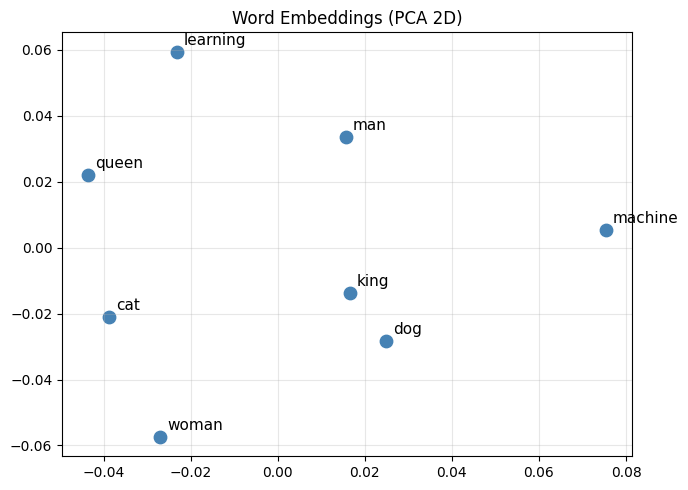

In [17]:
# Visualize word vectors with PCA
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

words_to_plot = ['king','queen','man','woman','dog','cat','machine','learning']
vecs = np.array([model.wv[w] for w in words_to_plot])
coords = PCA(n_components=2).fit_transform(vecs)

plt.figure(figsize=(7,5))
plt.scatter(coords[:,0], coords[:,1], c='steelblue', s=80)
for i, w in enumerate(words_to_plot):
    plt.annotate(w, xy=(coords[i,0], coords[i,1]), xytext=(5,5), textcoords='offset points', fontsize=11)
plt.title('Word Embeddings (PCA 2D)'); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
# Similar words (king/queen, dog/cat) should cluster together

> **Reference:** [GeeksForGeeks — Word2Vec](https://www.geeksforgeeks.org/word-embedding-using-word2vec/)

---
# SECTION 4: SENTIMENT ANALYSIS

## Definition
> **Sentiment Analysis** (Opinion Mining) is an NLP technique that identifies whether the expressed opinion in text is **positive**, **negative**, or **neutral**.

## Sub-Definitions
> **Polarity:** Direction of sentiment — positive (+1), negative (-1), neutral (0).

> **VADER:** A rule-based tool for social media. Handles ALL CAPS, `!!!`, emojis, and negation without training.

> **Compound Score:** VADER's summary score from -1 (most negative) to +1 (most positive). `≥0.05` = positive.

> **Lexicon:** A dictionary of words with pre-assigned sentiment scores. `"great"=+3.1`, `"terrible"=-2.8`.

## 3 Approaches
```
1. Rule-Based (VADER)     → no training, great for social media
2. ML (TF-IDF + LR)       → needs labeled data, fast, interpretable
3. Deep Learning (BERT)   → best accuracy, understands context
```

In [20]:
# Approach 1: VADER (no training needed)
from nltk.sentiment.vader import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()

texts = [
    "I LOVE this product!!!",
    "Terrible experience. Never buying again.",
    "The package arrived yesterday.",
    "Not bad at all :)",        # negation + emoji
]

print(f"{'Text':<40} {'Score':>7}  Label")
print('-'*58)
for text in texts:
    score = sia.polarity_scores(text)['compound']
    label = 'POS' if score >= 0.05 else ('NEG' if score <= -0.05 else 'NEU')
    print(f"{text:<40} {score:>7.3f}  {label}")

Text                                       Score  Label
----------------------------------------------------------
I LOVE this product!!!                     0.779  POS
Terrible experience. Never buying again.  -0.477  NEG
The package arrived yesterday.             0.000  NEU
Not bad at all :)                          0.705  POS


In [21]:
# Approach 2: TF-IDF + Logistic Regression
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

train_texts = [
    "absolutely loved this movie fantastic", "terrible film complete waste of time",
    "pretty good overall enjoyed it",         "awful acting and terrible script",
    "best movie i have seen in years",         "boring and predictable not recommended",
    "great performances by all cast",          "disappointing expected much better",
    "amazing cinematic experience",            "worst film i have ever watched",
]
train_labels = [1,0,1,0,1,0,1,0,1,0]

pipe = Pipeline([('tfidf', TfidfVectorizer(ngram_range=(1,2))),
                 ('lr',    LogisticRegression(max_iter=1000))])
pipe.fit(train_texts, train_labels)

tests = ["This product is absolutely wonderful!", "Total garbage, avoid at all costs"]
for t in tests:
    pred = pipe.predict([t])[0]
    prob = pipe.predict_proba([t])[0][pred]
    print(f"{'POS' if pred else 'NEG'} ({prob:.0%}) | {t}")

POS (55%) | This product is absolutely wonderful!
POS (54%) | Total garbage, avoid at all costs


In [ ]:
# Approach 3: BERT (best accuracy, uncomment after: pip install transformers)

# from transformers import pipeline
# clf = pipeline("sentiment-analysis")
# print(clf("This product is absolutely amazing!"))
# # → [{'label': 'POSITIVE', 'score': 0.999}]
# print(clf("I thought it would be bad but it was actually wonderful!"))
# # → [{'label': 'POSITIVE', 'score': 0.943}]  ← understands the reversal!

print("Uncomment above after: pip install transformers")

| Method | Accuracy | Speed | Training Data Needed |
|--------|---------|-------|---------------------|
| VADER | Medium | ⚡⚡⚡⚡⚡ | None |
| TF-IDF + LR | Good | ⚡⚡⚡⚡ | Yes (labeled) |
| BERT | Best | ⚡⚡ | Yes (or zero-shot) |

> **Reference:** [GeeksForGeeks — Sentiment Analysis](https://www.geeksforgeeks.org/twitter-sentiment-analysis-using-python/)